# Physical Characteristic–Based Predictive Modeling Using the ANSUR II Dataset

# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)

import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from lazypredict.Supervised import LazyClassifier
from yellowbrick.classifier import ClassPredictionError, ROCAUC

In [2]:
df_male = pd.read_csv("male.csv", encoding="latin1")
df_male.shape

(4082, 108)

In [3]:
df_male.head()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10027,266,1467,337,222,1347,253,202,401,369,...,Combat Arms,19D,North Dakota,1,NaN,1,41,71,180,Right hand
1,10032,233,1395,326,220,1293,245,193,394,338,...,Combat Support,68W,New York,1,NaN,1,35,68,160,Left hand
2,10033,287,1430,341,230,1327,256,196,427,408,...,Combat Support,68W,New York,2,NaN,2,42,68,205,Left hand
3,10092,234,1347,310,230,1239,262,199,401,359,...,Combat Service Support,88M,Wisconsin,1,NaN,1,31,66,175,Right hand
4,10093,250,1585,372,247,1478,267,224,435,356,...,Combat Service Support,92G,North Carolina,2,NaN,2,21,77,213,Right hand


In [4]:
df_female = pd.read_csv("female.csv", encoding="latin1")
df_female.shape

(1986, 108)

In [5]:
df_female.head()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10037,231,1282,301,204,1180,222,177,373,315,...,Combat Support,92Y,Germany,2,NaN,2,26,61,142,Right hand
1,10038,194,1379,320,207,1292,225,178,372,272,...,Combat Service Support,25U,California,3,Mexican,3,21,64,120,Right hand
2,10042,183,1369,329,233,1271,237,196,397,300,...,Combat Service Support,35D,Texas,1,NaN,1,23,68,147,Right hand
3,10043,261,1356,306,214,1250,240,188,384,364,...,Combat Service Support,25U,District of Columbia,8,Caribbean Islander,2,22,66,175,Right hand
4,10051,309,1303,308,214,1210,217,182,378,320,...,Combat Arms,42A,Texas,1,NaN,1,45,63,195,Right hand


In [6]:
df = pd.concat([df_male, df_female], axis=0, ignore_index=True)
df.head()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference,SubjectId
0,10027.00,266,1467,337,222,1347,253,202,401,369,...,19D,North Dakota,1,NaN,1,41,71,180,Right hand,NaN
1,10032.00,233,1395,326,220,1293,245,193,394,338,...,68W,New York,1,NaN,1,35,68,160,Left hand,NaN
2,10033.00,287,1430,341,230,1327,256,196,427,408,...,68W,New York,2,NaN,2,42,68,205,Left hand,NaN
3,10092.00,234,1347,310,230,1239,262,199,401,359,...,88M,Wisconsin,1,NaN,1,31,66,175,Right hand,NaN
4,10093.00,250,1585,372,247,1478,267,224,435,356,...,92G,North Carolina,2,NaN,2,21,77,213,Right hand,NaN


In [7]:
df.tail()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference,SubjectId
6063,NaN,285,1392,335,223,1297,252,196,368,299,...,42A,Texas,3,Mexican,3,51,67,180,Right hand,29501.00
6064,NaN,262,1324,301,202,1204,236,181,378,294,...,25U,Texas,3,Mexican,3,40,63,150,Right hand,29502.00
6065,NaN,260,1334,318,213,1259,234,183,363,332,...,42A,Texas,2,NaN,2,40,66,168,Right hand,29503.00
6066,NaN,205,1293,302,199,1207,213,163,376,276,...,92Y,Texas,3,Mexican,3,31,63,133,Right hand,29511.00
6067,NaN,238,1346,308,210,1256,236,188,361,285,...,92F,Texas,3,Mexican,3,27,66,132,Right hand,920103.00


In [8]:
df.shape

(6068, 109)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6068 entries, 0 to 6067
Columns: 109 entries, subjectid to SubjectId
dtypes: float64(2), int64(98), object(9)
memory usage: 5.0+ MB


In [10]:
string_cols = df.select_dtypes(include="object").columns

results = []

for col in string_cols:
    s = df[col].astype(str)

    results.append({
        "feature": col,
        "contains_space": s.str.contains(r"\s", na=False).sum(),
        "contains_?": s.str.contains(r"\?", na=False).sum(),
        "contains_non_alphanumeric": s.str.contains(r"[^a-zA-Z0-9_\- ]", na=False).sum(),
        "total_rows": len(s)
    })

results_df = pd.DataFrame(results)
results_df

# Veri setinde noise oluşturabilecek bir veri görülmemektedir.
# Non-alphanumeric olan sütunlarda veriler arasında "/" ve "()" işaretlerinin kullanıldğı görülmektedir. 

,feature,contains_space,contains_?,contains_non_alphanumeric,total_rows
0,Gender,0,0,0,6068
1,Date,0,0,0,6068
2,Installation,6068,0,0,6068
3,Component,6068,0,0,6068
4,Branch,6068,0,0,6068
5,PrimaryMOS,0,0,0,6068
6,SubjectsBirthLocation,1184,0,0,6068
7,Ethnicity,545,0,24,6068
8,WritingPreference,6068,0,62,6068


In [11]:
mask = df["Ethnicity"].str.contains(
    r"[^a-zA-Z0-9_\- ]",
    na=False
)

df_non_alnum = df.loc[mask, ["Ethnicity"]]
df_non_alnum

,Ethnicity
163,Guamanian/Chamorro
608,East/Asian Indian
902,East/Asian Indian
1076,Caribbean Islander East/Asian Indian
1200,East/Asian Indian
1364,East/Asian Indian
1454,East/Asian Indian
1845,East/Asian Indian
1874,Filipino Guamanian/Chamorro
1932,Métis Creole


In [12]:
mask = df["WritingPreference"].str.contains(
    r"[^a-zA-Z0-9_\- ]",
    na=False
)

df_non_alnum = df.loc[mask, ["WritingPreference"]]
df_non_alnum

,WritingPreference
11,Either hand (No preference)
165,Either hand (No preference)
188,Either hand (No preference)
204,Either hand (No preference)
210,Either hand (No preference)
...,...
5511,Either hand (No preference)
5597,Either hand (No preference)
5612,Either hand (No preference)
5986,Either hand (No preference)


In [13]:
for feature in df.columns:
    if df[feature].dtype=="object":
        print(feature, df[feature].nunique())

Gender 2
Date 253
Installation 12
Component 3
Branch 3
PrimaryMOS 285
SubjectsBirthLocation 152
Ethnicity 209
WritingPreference 3


In [14]:
df.PrimaryMOS.unique()

array(['19D', '68W', '88M', '92G', '91L', '91D', '92F', '25L', '91B',
       '25B', '42A', '15T', '15G', '15N', '15B', '92W', '14S', '14J',
       '25C', '94M', '94T', '25F', '25U', '15F', '92A', '92Y', '14E',
       '35F', '89B', '11C', '91M', '13F', '19K', '15U', '13B', '21B',
       '21H', '91A', '35G', '35P', '15W', '915A', '25N', '25Q', '94F',
       '25W', '250N', '25A', '35M', '351L', '351M', '25S', '31B', '31E',
       '12B', '12N', '21E', '68E', '12A', '74D', '68H', '68A', '68J',
       '92S', '68K', '70K', '88N', '91C', '70B', '91P', '13D', '13R',
       '27D', '11B', '79S', '91J', '91W', '91H', '11Z', '11A', '13A',
       '31A', '13S', '56A', '35D', '00Z', '35L', '43B', '27A', '14T',
       '36B', '91X', '91G', '19Z', '12Z', '18Z', '14Z', '92Z', '35X',
       '88Z', '68Z', '68S', '15P', '13Z', '56M', '79R', '91Z', '15Z',
       '35Z', '38B', '25Z', '19X', '25X', '51C', '21X', '46Z', '21Z',
       '92B', '42F', '89A', '13M', '21W', '12R', '12W', '12Y', '25P',
       '18F', '1

In [15]:
df.drop(["Date", "Installation", "PrimaryMOS"], axis = 1, inplace = True)

# Modele katkısı olmayacağı değerlendirilen feature'lar düşürülmüştür.

In [16]:
import pandas as pd

def column_info(df, sort_by_nan=True):
    info = []

    for col in df.columns:
        series = df[col]
        count = len(series)
        nan_count = series.isna().sum()
        non_nan_count = count - nan_count

        # güvenli sample
        sample_value = (
            series.dropna().iloc[0]
            if non_nan_count > 0
            else None
        )

        if pd.api.types.is_numeric_dtype(series):
            min_value = series.min()
            max_value = series.max()
        else:
            min_value = None
            max_value = None

        info.append({
            "Column_Name": col,
            "Data_Type": series.dtype,
            "Count": count,
            "NaN_Count": nan_count,
            "NaN_%": round((nan_count / count) * 100, 2) if count > 0 else 0,
            "Unique_Count": series.nunique(dropna=True),
            "Min_Value": min_value,
            "Max_Value": max_value,
            "Sample_Value": sample_value
        })

    info_df = pd.DataFrame(info)

    if sort_by_nan:
        info_df = (
            info_df
            .sort_values("NaN_%", ascending=False)
            .reset_index(drop=True)
        )

    return info_df

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [17]:
column_info(df)

# Ethnicity sütununda yüksek oranda NaN değer oldğu görülmektedir.

,Column_Name,Data_Type,Count,NaN_Count,NaN_%,Unique_Count,Min_Value,Max_Value,Sample_Value
0,Ethnicity,object,6068,4647,76.58,209,NaN,NaN,Mexican Yaqui
1,SubjectId,float64,6068,4082,67.27,1986,10037.00,920103.00,10037.00
2,subjectid,float64,6068,1986,32.73,4082,10027.00,29452.00,10027.00
3,acromionradialelength,int64,6068,0,0.00,133,249.00,393.00,337
4,acromialheight,int64,6068,0,0.00,432,1115.00,1683.00,1467
5,axillaheight,int64,6068,0,0.00,402,1038.00,1553.00,1347
6,balloffootcircumference,int64,6068,0,0.00,107,186.00,306.00,253
7,balloffootlength,int64,6068,0,0.00,86,151.00,245.00,202
8,anklecircumference,int64,6068,0,0.00,112,156.00,293.00,222
9,abdominalextensiondepthsitting,int64,6068,0,0.00,218,155.00,451.00,266


In [18]:
df.drop(["SubjectId", "subjectid"], axis = 1, inplace = True)

# Modele katkısı olmayacağı değerlendirilen feature'lar düşürülmüştür.

In [19]:
# "Ethnicity" sütunundaki NaN değerler, bu feature ile yakın olduğu değerlendirilen "SubjectsBirthLocation" ve "SubjectNumericRace" sütunları groupby yapılarak tespit edilen mode değeri ile doldurulmuştur.

mode_map = (
    df.groupby(["SubjectsBirthLocation", "SubjectNumericRace"])["Ethnicity"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)

df = df.merge(mode_map,
              on=["SubjectsBirthLocation", "SubjectNumericRace"],
              how="left",
              suffixes=("", "_mode"))

df["Ethnicity"] = df["Ethnicity"].fillna(df["Ethnicity_mode"])

df.drop(columns=["Ethnicity_mode"], inplace=True)

In [20]:
# Yüksek kardinaliteye sahip "Ethnicity" sütunu değerleri üst gruplarda sınıflandırılarak encoding için uygun hale getirilmiştir.

import re

HISPANIC = {
    "Mexican", "Puerto", "Puerto Rican", "Cuban", "Salvadoran",
    "Colombian", "Guatemalan", "Honduran", "Nicaraguan",
    "Panamanian", "Peruvian", "Chilean", "Argentine",
    "Ecuadorian", "Bolivian", "Brazilian", "Costa", "Venezuelan",
    "Belizean", "Paraguayan", "Dominican", "Aztec", "Yaqui", "Pima", "Zuni"
}

ASIAN = {
    "Japanese", "Chinese", "Korean", "Filipino", "Vietnamese",
    "Thai", "Cambodian", "Laotian", "Hmong", "Taiwanese",
    "Nepali", "Sri", "Indian", "Malaysian", "Indonesian",
    "Burmese"
}

NATIVE_AMERICAN = {
    "Cherokee", "Navajo", "Apache", "Sioux", "Lakota", "Ojibwe",
    "Choctaw", "Chickasaw", "Blackfoot", "Comanche", "Cree",
    "Cheyenne", "Seminole", "Chippewa", "Shawnee", "Osage",
    "Pueblo", "Ute", "Kiowa", "Potawatomi", "Iroquois",
    "Algonquin", "Crow", "Zuni", "Yaqui", "Oneida"
}

def map_ethnicity_upper_group(ethnicity):
    if pd.isna(ethnicity):
        return "Other"

    tokens = ethnicity.replace("/", " ").split()
    tokens = set(tokens)

    if tokens & HISPANIC:
        return "Hispanic / Latino"

    if tokens & ASIAN:
        return "Asian"

    if tokens & NATIVE_AMERICAN:
        return "Native American / Indigenous"

    return "Other"

In [21]:
df["Ethnicity"] = df["Ethnicity"].apply(map_ethnicity_upper_group)

In [22]:
df["Ethnicity"].value_counts()

Ethnicity
Other                           4845
Hispanic / Latino                796
Asian                            268
Native American / Indigenous     159
Name: count, dtype: int64

In [23]:
# Yüksek kardinaliteye sahip "SubjectsBirthLocation" sütunu değerleri üst gruplarda sınıflandırılarak encoding için uygun hale getirilmiştir.

US_STATES = {
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado",
    "Connecticut","Delaware","Florida","Georgia","Hawaii","Idaho",
    "Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana","Maine",
    "Maryland","Massachusetts","Michigan","Minnesota","Mississippi",
    "Missouri","Montana","Nebraska","Nevada","New Hampshire","New Jersey",
    "New Mexico","New York","North Carolina","North Dakota","Ohio",
    "Oklahoma","Oregon","Pennsylvania","Rhode Island","South Carolina",
    "South Dakota","Tennessee","Texas","Utah","Vermont","Virginia",
    "Washington","West Virginia","Wisconsin","Wyoming",
    "District of Columbia"
}

US_TERRITORIES = {
    "Puerto Rico","Guam","US Virgin Islands","British Virgin Islands",
    "American Samoa","Northern Mariana Islands"
}

LATIN_AMERICA = {
    "Mexico","Colombia","El Salvador","Peru","Cuba","Dominican Republic",
    "Brazil","Haiti","Jamaica","Nicaragua","Costa Rica","Belize",
    "Ecuador","Bolivia","Chile","Argentina","Paraguay","Venezuela",
    "Guatemala","Panama","Honduras","Grenada","Bahamas","Barbados",
    "Trinidad and Tobago","Saint Lucia","Dominica","French Guiana",
    "Guadalupe"
}

EUROPE = {
    "Romania","Netherlands","Belgium","Germany","United Kingdom",
    "Ukraine","Portugal","France","Russia","Italy","Poland","Iceland",
    "Bulgaria","Serbia","Bosnia and Herzegovina","Denmark"
}

ASIA = {
    "Philippines","Vietnam","Taiwan","Japan","South Korea","India",
    "Nepal","China","Singapore","Thailand","Cambodia","Laos","Sri Lanka",
    "Bangladesh","Azerbaijan","Iran","Iraq","Israel","Lebanon","Syria",
    "Turkey","Burma","Korea"
}

AFRICA = {
    "Morocco","Cameroon","Nigeria","Sierra Leone","Senegal","Sudan",
    "Liberia","South Africa","Kenya","Ethiopia","Ghana","Egypt","Togo",
    "Ivory Coast","Zambia","Cape Verde"
}

OCEANIA = {
    "Palau","Micronesia","Fiji","New Zealand"
}

def map_birth_location(location):
    if pd.isna(location):
        return "Unknown"

    if location in US_STATES:
        return "USA"

    if location in US_TERRITORIES:
        return "US_Territory"

    if location in LATIN_AMERICA:
        return "Latin_America"

    if location in EUROPE:
        return "Europe"

    if location in ASIA:
        return "Asia"

    if location in AFRICA:
        return "Africa"

    if location in OCEANIA:
        return "Oceania"

    if location in {"United States"}:
        return "USA"

    if location in {"South America"}:
        return "Latin_America"

    return "Other"

In [24]:
df["SubjectsBirthLocation"] = df["SubjectsBirthLocation"].apply(map_birth_location)

In [25]:
df["SubjectsBirthLocation"].value_counts()

SubjectsBirthLocation
USA              5408
Latin_America     190
Europe            146
Asia              146
US_Territory      115
Africa             35
Other              22
Oceania             6
Name: count, dtype: int64

In [26]:
df.DODRace.unique()

array([1, 2, 3, 4, 5, 6, 8])

In [27]:
df["DODRace"].value_counts()

DODRace
1    3792
2    1298
3     679
4     188
6      59
5      49
8       3
Name: count, dtype: int64

In [28]:
THRESHOLD = 500

vc = df["DODRace"].value_counts()

major_classes = vc[vc >= THRESHOLD].index

df["DODRace"] = df["DODRace"].where(
    df["DODRace"].isin(major_classes),
    "Other")

df["DODRace"].value_counts()

# Sayısı 500'den az olan sınıflar "other" sınıfı altında toplanmıştır.

DODRace
1        3792
2        1298
3         679
Other     299
Name: count, dtype: int64

In [29]:
df['DODRace'] = df['DODRace'].map({1: 0, 2: 1, 3: 2, 'Other':3})

# XGBoost algoritması için target sınıflarının indeksi 0'dan başlayacak şekilde ayarlanmıştır.

In [30]:
df["DODRace"].value_counts()

DODRace
0    3792
1    1298
2     679
3     299
Name: count, dtype: int64

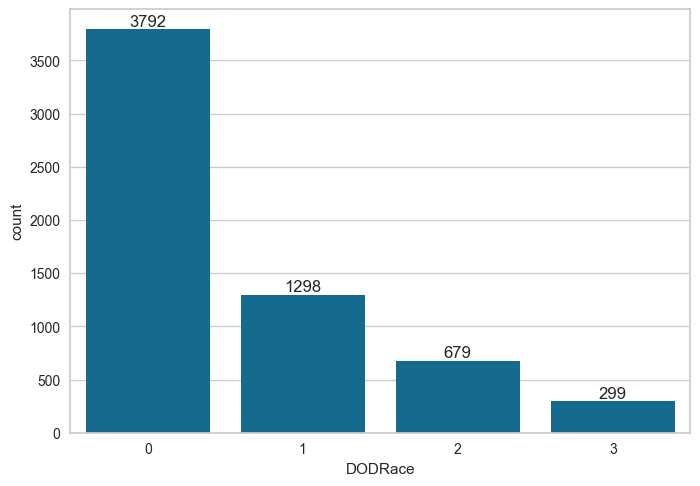

In [31]:
ax = sns.countplot(x = "DODRace", data = df)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# Target sınıfının unbalanced bir yapıda olduğu görülmektedir.

In [32]:
cols = ['Ethnicity', 'Gender', 'Component', 'SubjectsBirthLocation', 'Branch', 'WritingPreference']

encoded_df = pd.get_dummies(df[cols], drop_first=True, dtype= int)

df = df.drop(columns=cols)

df = pd.concat([df, encoded_df], axis=1)

df.head()

# One-hot-encoding ile object tipindeki veriler numeric tipe dönüştürülmüştür.

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,SubjectNumericRace,DODRace,Age,Heightin,Weightlbs,Ethnicity_Hispanic / Latino,Ethnicity_Native American / Indigenous,Ethnicity_Other,Gender_Male,Component_Army Reserve,Component_Regular Army,SubjectsBirthLocation_Asia,SubjectsBirthLocation_Europe,SubjectsBirthLocation_Latin_America,SubjectsBirthLocation_Oceania,SubjectsBirthLocation_Other,SubjectsBirthLocation_USA,SubjectsBirthLocation_US_Territory,Branch_Combat Service Support,Branch_Combat Support,WritingPreference_Left hand,WritingPreference_Right hand
0,266,1467,337,222,1347,253,202,401,369,274,493,71,319,291,142,979,240,882,619,509,373,1535,291,1074,259,1292,877,607,351,36,71,19,247,802,101,273,349,299,575,477,1136,90,214,193,150,583,206,326,70,332,366,1071,685,422,441,502,560,500,77,391,118,400,436,1447,113,437,273,1151,368,145,928,883,600,1782,1776,1449,1092,610,164,786,491,140,919,1700,501,329,933,240,440,1054,815,175,853,1,0,41,71,180,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,1
1,233,1395,326,220,1293,245,193,394,338,257,479,67,344,320,135,944,232,870,584,468,357,1471,269,1021,253,1244,851,615,376,33,62,18,232,781,98,263,348,289,523,476,1096,86,203,195,146,568,201,334,72,312,356,1046,620,441,447,490,540,488,73,371,131,380,420,1380,118,417,254,1119,353,141,884,868,564,1745,1702,1387,1076,572,169,822,476,120,918,1627,432,316,870,225,371,1054,726,167,815,1,0,35,68,160,0,0,1,1,0,1,0,0,0,0,0,1,0,0,1,1,0
2,287,1430,341,230,1327,256,196,427,408,261,544,75,345,330,135,1054,258,901,623,506,412,1501,288,1120,267,1288,854,636,359,40,61,23,237,810,103,270,355,357,575,491,1115,93,220,203,148,573,202,356,70,349,393,1053,665,462,475,496,556,482,72,409,123,403,434,1447,121,431,268,1276,367,167,917,910,604,1867,1735,1438,1105,685,198,807,477,125,918,1678,472,329,964,255,411,1041,929,180,831,2,1,42,68,205,0,0,1,1,0,1,0,0,0,0,0,1,0,0,1,1,0
3,234,1347,310,230,1239,262,199,401,359,262,518,73,328,309,143,991,242,821,560,437,395,1423,296,1114,262,1205,769,590,341,39,66,25,272,794,106,267,352,318,593,467,1034,91,217,194,158,576,199,341,68,338,367,986,640,458,461,460,511,452,76,393,106,407,446,1357,118,393,249,1155,330,148,903,848,550,1708,1655,1346,1021,604,180,803,445,127,847,1625,461,315,857,205,399,968,794,176,793,1,0,31,66,175,0,0,1,1,0,1,0,0,0,0,0,1,0,1,0,0,1
4,250,1585,372,247,1478,267,224,435,356,263,524,80,340,310,138,1029,275,1080,706,567,425,1684,304,1048,232,1452,1014,68

In [33]:
df.shape

(6068, 115)

In [34]:
df.isnull().sum().sum()

np.int64(0)

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
abdominalextensiondepthsitting,6068.00,246.47,37.40,155.00,219.00,242.00,271.00,451.00
acromialheight,6068.00,1406.16,79.09,1115.00,1350.00,1410.00,1462.00,1683.00
acromionradialelength,6068.00,327.37,20.72,249.00,313.00,328.00,341.25,393.00
anklecircumference,6068.00,224.89,16.05,156.00,214.00,225.00,235.00,293.00
axillaheight,6068.00,1299.61,72.02,1038.00,1249.00,1302.00,1349.00,1553.00
balloffootcircumference,6068.00,244.19,16.85,186.00,232.00,245.00,256.00,306.00
balloffootlength,6068.00,194.75,13.52,151.00,185.00,195.00,204.00,245.00
biacromialbreadth,6068.00,399.20,30.24,283.00,376.00,404.00,421.00,489.00
bicepscircumferenceflexed,6068.00,340.93,41.52,216.00,311.00,341.00,370.00,490.00
bicristalbreadth,6068.00,274.74,19.22,197.00,262.00,274.00,288.00,362.00


In [37]:
correlation_matrix = df.corr()

def color_corr(val):
    color = ''
    if abs(val) == 1:
        color = 'background-color: #FF6666'  # Mükemmel Korelasyon için kırmızı
    elif 0.7 <= abs(val) < 1:
        color = 'background-color: #FFB266'  # Yüksek Korelasyon için turuncu
    elif 0.3 <= abs(val) < 0.7:
        color = 'background-color: #0000FF'  # Orta Korelasyon için mavi
    elif 0.1 <= abs(val) < 0.3:
        color = 'background-color: #33CC33'  # Düşük Korelasyon için yeşil
    elif abs(val) == 0:
        color = 'background-color: #FFFFFF'  # Korelasyon yok için beyaz
    return color

styled_corr_matrix = correlation_matrix.style.applymap(color_corr)
styled_corr_matrix = styled_corr_matrix.format(precision=2)
styled_corr_matrix.set_caption("Correlation Matrix ")
styled_corr_matrix

# Bağımlı ve bağımsız değişkenler arasındaki korelasyon incelenmiştir.

In [38]:
df.corr()["DODRace"].drop("DODRace").sort_values(ascending=False)

# Target değişken ile yüksek korelasyona sahip feature'lar incelenmiştir.

Ethnicity_Hispanic / Latino               0.53
SubjectsBirthLocation_Asia                0.34
SubjectsBirthLocation_US_Territory        0.22
SubjectsBirthLocation_Latin_America       0.20
interpupillarybreadth                     0.15
bizygomaticbreadth                        0.10
heelbreadth                               0.09
Component_Regular Army                    0.09
SubjectsBirthLocation_Oceania             0.07
Ethnicity_Native American / Indigenous    0.06
headbreadth                               0.05
bitragionchinarc                          0.05
Component_Army Reserve                    0.04
Branch_Combat Support                     0.04
Branch_Combat Service Support             0.03
WritingPreference_Right hand              0.02
SubjectNumericRace                        0.02
SubjectsBirthLocation_Other               0.01
Age                                       0.01
WritingPreference_Left hand              -0.02
tragiontopofhead                         -0.02
bitragionsubm

## PCA

In [39]:
from sklearn.preprocessing import scale

df_scaled = scale(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

stats_df = df_scaled.describe().loc[["count", "mean", "std"]]

stats_df

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,SubjectNumericRace,DODRace,Age,Heightin,Weightlbs,Ethnicity_Hispanic / Latino,Ethnicity_Native American / Indigenous,Ethnicity_Other,Gender_Male,Component_Army Reserve,Component_Regular Army,SubjectsBirthLocation_Asia,SubjectsBirthLocation_Europe,SubjectsBirthLocation_Latin_America,SubjectsBirthLocation_Oceania,SubjectsBirthLocation_Other,SubjectsBirthLocation_USA,SubjectsBirthLocation_US_Territory,Branch_Combat Service Support,Branch_Combat Support,WritingPreference_Left hand,WritingPreference_Right hand
count,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00,6068.00
mean,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1

In [40]:
df_pca = pd.DataFrame(df_scaled, columns=df.columns)
df_pca.head()

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,SubjectNumericRace,DODRace,Age,Heightin,Weightlbs,Ethnicity_Hispanic / Latino,Ethnicity_Native American / Indigenous,Ethnicity_Other,Gender_Male,Component_Army Reserve,Component_Regular Army,SubjectsBirthLocation_Asia,SubjectsBirthLocation_Europe,SubjectsBirthLocation_Latin_America,SubjectsBirthLocation_Oceania,SubjectsBirthLocation_Other,SubjectsBirthLocation_USA,SubjectsBirthLocation_US_Territory,Branch_Combat Service Support,Branch_Combat Support,WritingPreference_Left hand,WritingPreference_Right hand
0,0.52,0.77,0.46,-0.18,0.66,0.52,0.54,0.06,0.68,-0.04,0.05,-0.23,-0.35,-0.75,0.31,-0.54,-0.06,0.22,0.30,0.41,-0.43,0.68,0.39,0.52,0.27,0.50,0.95,-0.33,-0.01,0.27,1.72,-1.03,0.21,0.38,0.32,0.57,0.44,0.13,0.37,0.33,0.50,0.80,0.65,0.32,-0.35,0.71,1.14,-0.29,-0.13,-0.65,-0.61,0.52,1.44,0.23,0.22,0.80,0.58,0.57,1.02,-0.47,-0.19,0.62,0.58,0.68,-0.13,0.67,0.70,0.23,0.62,-0.01,0.66,0.28,0.60,0.16,0.68,0.58,-0.13,-0.21,-0.76,-0.07,1.10,1.56,0.67,0.71,1.10,0.31,0.16,0.29,1.99,0.36,0.11,0.46,0.48,-0.03,-0.67,1.30,0.71,0.16,-0.39,-0.16,0.50,0.70,-0.19,0.97,-0.16,-0.16,-0.18,-0.03,-0.06,0.35,-0.14,-1.05,-0.53,-0.35,0.37
1,-0.36,-0.14,-0.07,-0.30,-0.09,0.05,-0.13,-0.17,-0.07,-0.92,-0.28,-0.98,1.12,0.64,-0.65,-1.00,-0.36,-0.00,-0.74,-1.00,-0.95,-0.08,-0.67,-0.01,0.05,-0.10,0.47,-0.15,0.82,-0.66,-0.13,-1.34,-0.31,-0.12,-0.13,-0.00,0.40,-0.20,-0.47,0.30,-0.09,0.16,-0.06,0.50,-0.99,-0.11,0.55,0.06,0.21,-1.44,-0.92,0.10,-0.35,0.67,0.38,0.44,-0.00,0.16,0.47,-1.07,1.46,0.11,0.16,-0.10,0.57,0.03,-0.26,-0.11,-0.05,-0.33,-0.31,0.02,-0.34,-0.17,-0.14,-0.20,-0.39,-0.87,-0.45,0.60,0.60,-1.44,0.65,-0.03,-0.78,-0.05,-0.39,-0.13,-0.19,0.36,-0.45,-0.15,-0.32,-0.03,-0.67,0.60,-0.07,-0.44,-0.39,-0.16,0.50,0.70,-0.19,0.97,-0.16,-0.16,-0.18,-0.03,-0.06,0.35,-0.14,-1.05,1.90,2.87,-2.73
2,1.08,0.30,0.66,0.32,0.38,0.70,0.09,0.92,1.62,-0.71,1.26,0.51,1.18,1.12,-0.65,0.44,0.62,0.56,0.41,0.31,0.85,0.28,0.25,0.97,0.57,0.45,0.53,0.31,0.26,1.51,-0.33,0.23,-0.14,0.58,0.62,0.40,0.70,2.06,0.37,0.80,0.19,1.27,1.04,1.19,-0.67,0.16,0.67,1.04,-0.13,0.02,0.22,0.22,0.89,1.16,1.10,0.62,0.46,-0.04,0.33,0.08,0.44,0.69,0.53,0.68,0.99,0.47,0.45,1.58,0.57,1.77,0.42,0.75,0.71,0.93,0.23,0.45,0.09,1.09,1.34,0.32,0.63,-0.69,0.65,0.48,0.31,0.31,0.43,0.71,1.08,0.15,0.84,0.84,0.02,-0.03,0.47,1.41,-0.07,0.90,-0.39,-0.16,0.50,0.70,-0.19,0.97,-0.16,-0.16,-0.18,-0.03,-0.06,0

In [41]:
import prince
pca = prince.PCA(rescale_with_mean=False,
    rescale_with_std=False,
    n_components=16,
    n_iter=10,
    copy=True,
    check_input=True,
    random_state=42,
    engine='sklearn')

pca = pca.fit(df_pca)

In [42]:
eigenvalues = pca.eigenvalues_
eigenvalues

array([54.2421857 , 12.02825608,  5.30414954,  3.32722011,  2.57921476,
        2.19962747,  1.96667545,  1.67255349,  1.52662475,  1.50191197,
        1.37084752,  1.20847345,  1.18740959,  1.16894373,  1.08126357,
        1.05313183])

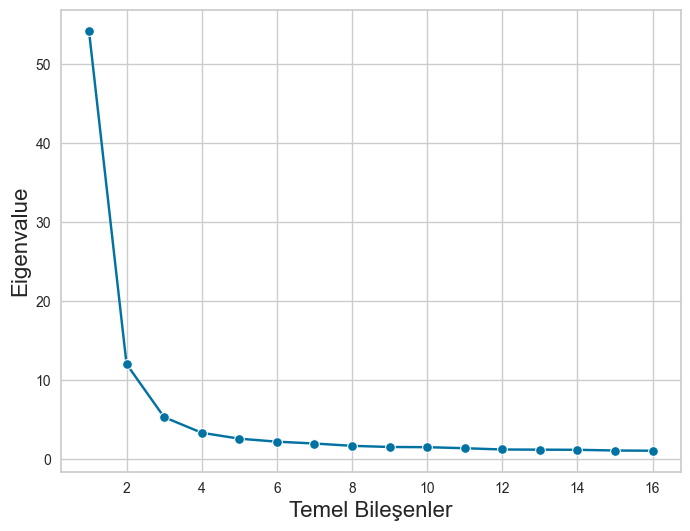

In [43]:
# Elbow metodu ile optimum temel bileşen sayısı seçimi

ev = pd.DataFrame()
ev["pca"] = range(1,17)
ev["eigenvalue"]=pd.DataFrame(pca.eigenvalues_)
plt.figure(figsize=(8,6))
sns.lineplot(x="pca", y = "eigenvalue", marker = "o", data= ev)
plt.ylabel("Eigenvalue", fontsize=16)
plt.xlabel("Temel Bileşenler", fontsize=16)
plt.show()

In [44]:
explained_variance = pca.cumulative_percentage_of_variance_
explained_variance

array([47.167118  , 57.62647112, 62.23877507, 65.13200995, 67.37480539,
       69.28752493, 70.9976775 , 72.45207183, 73.77957161, 75.08558202,
       76.27762334, 77.32846982, 78.3609999 , 79.37747271, 80.3177019 ,
       81.23346871])

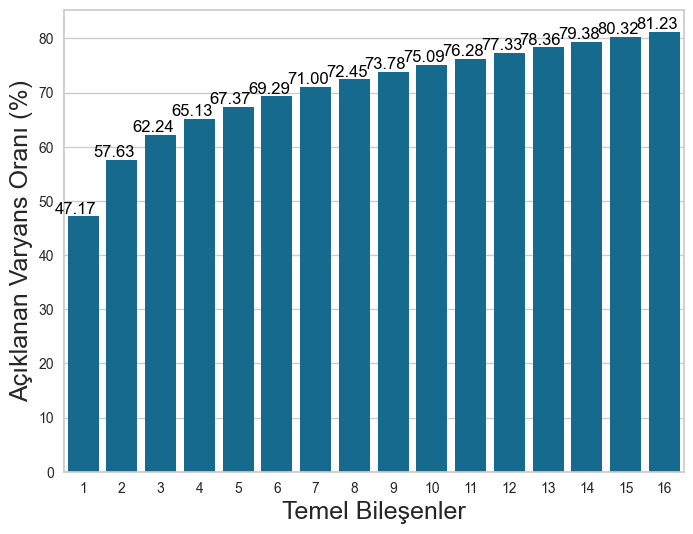

In [45]:
avo = pd.DataFrame()
avo["pca"] = range(1,17)
avo["vari"] = pd.DataFrame(pca.cumulative_percentage_of_variance_)

plt.figure(figsize=(8,6))
graph = sns.barplot(x="pca", y ="vari", data=avo)

for p in graph.patches :
    graph.annotate('{:.2f}'.format(p.get_height()),(p.get_x()+0.2,p.get_height()), ha="center", va="bottom", color="black")

plt.ylabel("Açıklanan Varyans Oranı (%)", fontsize=18)
plt.xlabel("Temel Bileşenler", fontsize=18)
plt.show()

# Ancak 16 bileşenli bir model ile verinin %80 ve yukarısı temsil edilebiliyor.

In [46]:
correlations = pca.column_correlations
correlations 
# Temel bileşenler ile featureların korelasyonu

component,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
variable,,,,,,,,,,,,,,,,
abdominalextensiondepthsitting,-0.59,-0.66,0.08,0.07,-0.07,-0.26,-0.01,0.01,0.03,0.04,-0.02,-0.05,-0.03,0.03,0.03,-0.04
acromialheight,-0.92,0.29,0.14,-0.12,0.14,-0.05,-0.01,-0.01,0.02,0.03,0.02,-0.00,0.01,-0.02,0.04,-0.04
acromionradialelength,-0.83,0.31,0.16,0.05,-0.01,-0.11,-0.00,0.03,-0.01,0.03,-0.05,0.02,-0.02,-0.02,-0.08,0.03
anklecircumference,-0.68,-0.33,0.01,-0.06,-0.01,0.37,0.00,0.00,0.00,-0.20,0.15,-0.09,-0.11,-0.07,-0.06,0.00
axillaheight,-0.88,0.36,0.17,-0.11,0.14,-0.03,-0.00,-0.01,0.02,0.03,0.02,0.01,0.02,-0.02,0.04,-0.03
balloffootcircumference,-0.83,-0.06,-0.22,0.00,-0.03,0.22,-0.01,-0.02,0.03,-0.14,0.17,-0.06,-0.07,0.03,-0.02,0.01
balloffootlength,-0.85,0.21,-0.06,0.11,-0.06,0.11,-0.01,0.03,0.02,-0.06,0.15,-0.05,-0.03,-0.03,0.00,0.02
biacromialbreadth,-0.85,0.05,-0.29,-0.04,-0.07,0.00,0.04,0.07,-0.08,-0.06,-0.14,0.09,0.04,-0.04,-0.08,0.07
bicepscircumferenceflexed,-0.76,-0.43,-0.15,0.07,-0.13,0.01,-0.03,0.05,-0.02,-0.10,-0.03,0.04,0.01,-0.04,0.08,-0.06


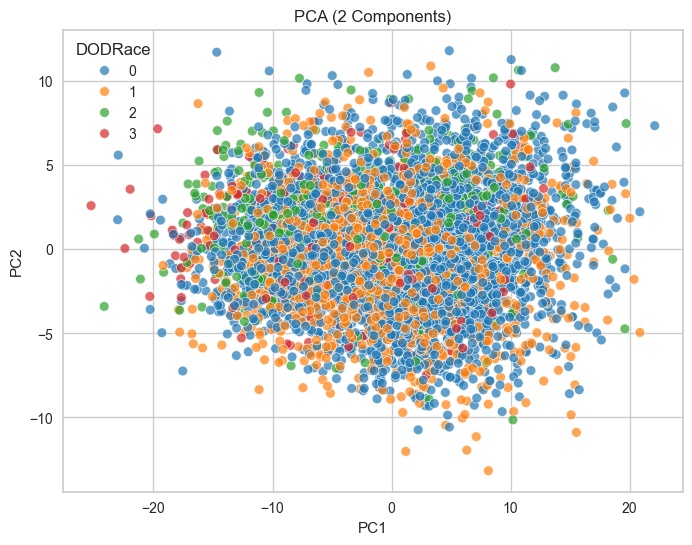

In [47]:
# Linear global varyans

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop(columns="DODRace")
y = df["DODRace"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "DODRace": y
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="DODRace",
    palette="tab10",
    alpha=0.7
)
plt.title("PCA (2 Components)")
plt.show()

# Renkler (DODRace = 0,1,2,3) belirgin kümeler oluşturmuyor, PC1–PC2 düzleminde net ayrışma yok ve her sınıf diğerlerinin üzerine binmiş durumda.
# Bazı fiziksel ölçüler (boy, kilo, çevre ölçüleri) herkes için benzer varyansa sahip ama ırk ayrımı bu ölçülerde zayıf.
# Merkez etrafında yoğunlaşma var, outlier’lar mevcut ama sınıfa özgü değil. 
# PC1 daha geniş varyans taşıyor (x ekseni daha yaygın) ve birçok feature aynı yönde birlikte değişiyor (yukarıdaki correlations dataframe'de görüldüğü gibi vektör yönlerinin çoğu (-) yön).
# Bu durumun açıklaması: Feature'lar bağımsız bilgi taşımıyor, aynı bilgiyi tekrar ediyor, noktalar bir eksen (PC1) boyunca uzun bir elips gibi yayılmış.
# Logistic Regression ve Linear SVC gibi lineae modellerde düşük düşük recall / precision skorları beklenebilir.
# RF, XGBoost ve RBF SVC gibi non-linear modellerde daha iyi performans görülebilir.

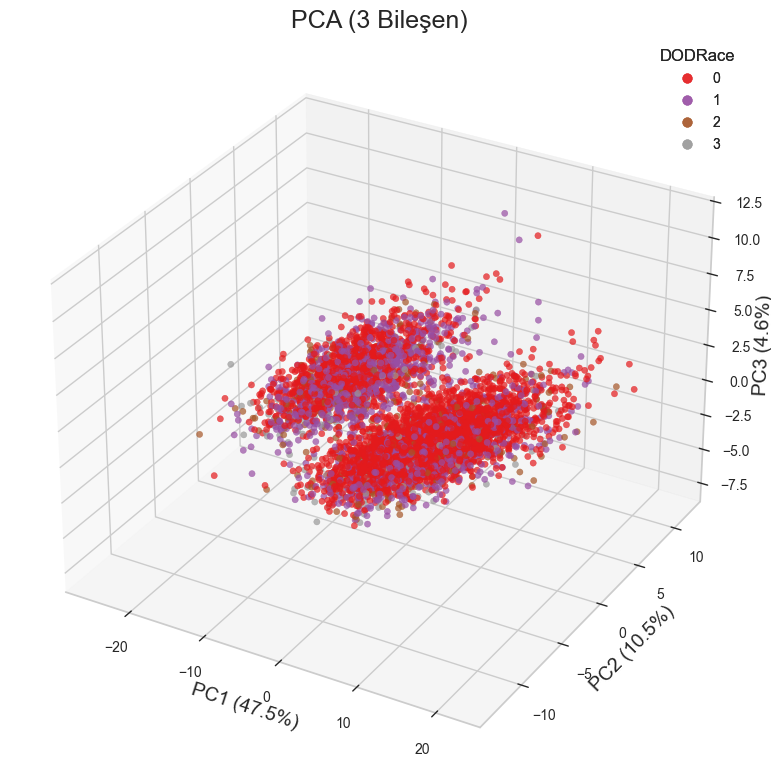

In [48]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=df["DODRace"].values,   
    s=20,                    
    alpha=0.7,                
    cmap="Set1"
)

var = pca.explained_variance_ratio_ * 100

ax.set_title("PCA (3 Bileşen)", fontsize=18)
ax.set_xlabel(f"PC1 ({var[0]:.1f}%)", fontsize=14)
ax.set_ylabel(f"PC2 ({var[1]:.1f}%)", fontsize=14)
ax.set_zlabel(f"PC3 ({var[2]:.1f}%)", fontsize=14)

legend = ax.legend(
    *scatter.legend_elements(),
    title="DODRace"
)
ax.add_artist(legend)

plt.tight_layout()
plt.show()

# Vücuttaki genel boyut / hacim farkları yakalanmış; ancak 0,1,2,3 renkleri neredeyse tamamen üst üste, ayrı ayrı “bulutlar” yok, sınıfa özgü net bölgeler oluşmamış.
# Birbirine paralel, yatay iki yoğun kütle boy–kilo–çevre kombinasyonları veya male/female body-size profilleri üzerinden ayrılmış olabilir. 
# Ancak bu durum DODRace sınıfları ile çakışmıyor ve sınıf renkleri her iki kütlede de karışık durumda. 
# Logistic Regression ve Linear SVC gibi lineae modellerde düşük accuracy / macro-F1 skorları beklenebilir.
# RF, XGBoost ve RBF SVC gibi non-linear modellerde daha iyi performans görülebilir.

# DATA Preprocessing

In [49]:
X = df.drop(columns="DODRace")
y = df["DODRace"]

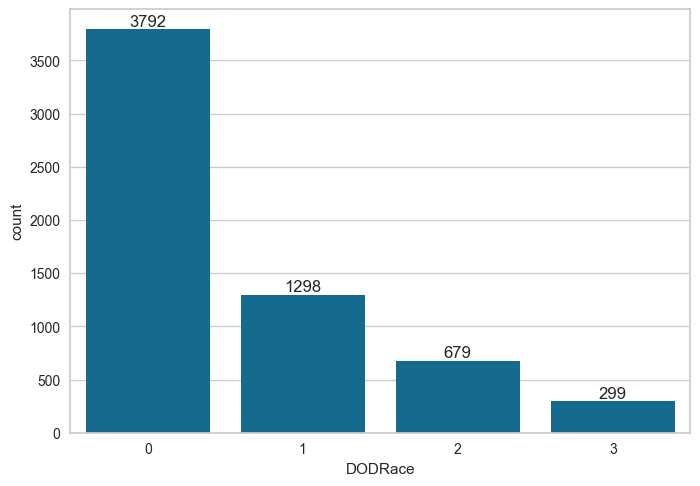

In [50]:
ax = sns.countplot(x = "DODRace", data = df)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [52]:
train_counts = y_train.value_counts().rename("train")
test_counts = y_test.value_counts().rename("test")

class_distribution = pd.concat([train_counts, test_counts], axis=1)
class_distribution

,train,test
DODRace,,
0,3034,758
1,1038,260
2,543,136
3,239,60


# Modelling

## Logistic model

### Vanilla LR

In [54]:
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [55]:
pipe_logistic = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

pipe_logistic.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,penalty,'l2'


In [56]:
y_pred_log = pipe_logistic.predict(X_test)

In [57]:
log_reg_accuracy = accuracy_score(y_test, y_pred_log)
log_reg_f1 = f1_score(y_test, y_pred_log, average='macro')

In [58]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [59]:
eval_metric(pipe_logistic, X_train, y_train, X_test, y_test)

Test_Set
[[709  15  13  21]
 [ 13 242   2   3]
 [  4   3 127   2]
 [  8   2   2  48]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       758
           1       0.92      0.93      0.93       260
           2       0.88      0.93      0.91       136
           3       0.65      0.80      0.72        60

    accuracy                           0.93      1214
   macro avg       0.86      0.90      0.88      1214
weighted avg       0.93      0.93      0.93      1214


Train_Set
[[2855   57   46   76]
 [  39  968   15   16]
 [   2    5  532    4]
 [   9    3    3  224]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3034
           1       0.94      0.93      0.93      1038
           2       0.89      0.98      0.93       543
           3       0.70      0.94      0.80       239

    accuracy                           0.94      4854
   macro avg       0.88      0.95      0.91      

In [60]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

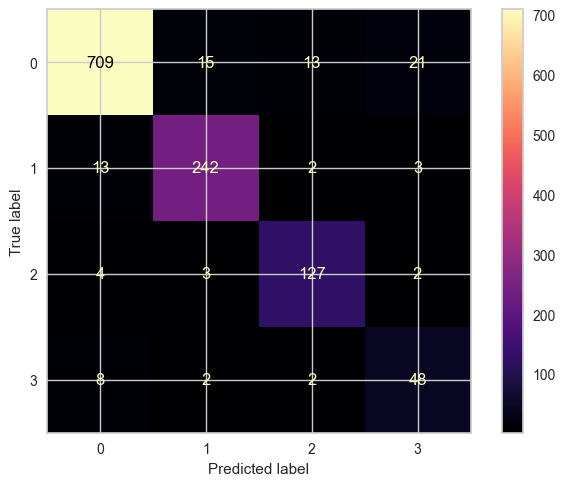

In [61]:
ConfusionMatrixDisplay.from_estimator(pipe_logistic, X_test, y_test, cmap = 'magma');

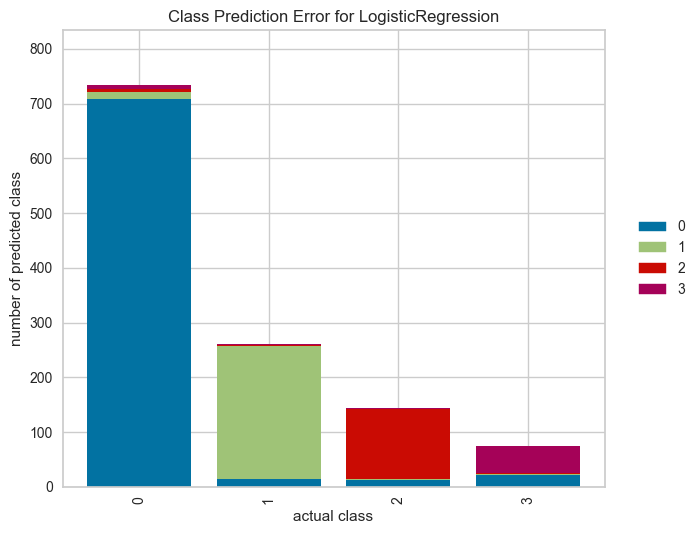

<Axes: title={'center': 'Class Prediction Error for LogisticRegression'}, xlabel='actual class', ylabel='number of predicted class'>

In [62]:
visualizer = ClassPredictionError(pipe_logistic)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

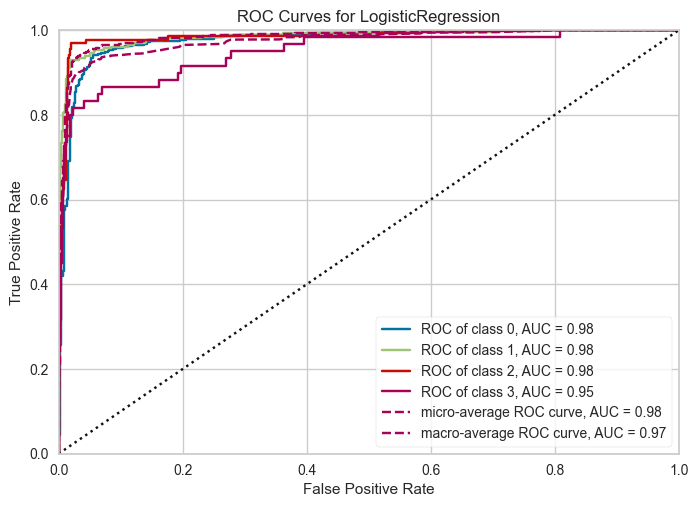

<Axes: title={'center': 'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [63]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(pipe_logistic, classes=[str(i) for i in range(4)])

visualizer.fit(X_train, y_train)        
visualizer.score(X_test, y_test)        
visualizer.show() 

### LR GridSearchCV

In [64]:
param_grid = {
    "model__solver": ["lbfgs", "newton-cg", "saga"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_grid = GridSearchCV(
    estimator=pipe_logistic,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

log_grid.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs', 'newton-cg', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [65]:
log_grid.best_params_

{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

In [66]:
log_grid.best_score_

np.float64(0.9229526367757759)

In [67]:
log_grid.best_estimator_

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,penalty,'l2'


In [68]:
y_pred_test = log_grid.predict(X_test)
y_pred_train = log_grid.predict(X_train)

In [69]:
log_grid_accuracy = accuracy_score(y_test, y_pred_test)
log_grid_f1 = f1_score(y_test, y_pred_test, average='macro')

In [70]:
eval_metric(log_grid, X_train, y_train, X_test, y_test)

Test_Set
[[714  14  12  18]
 [ 16 234   6   4]
 [  1   3 132   0]
 [  5   2   2  51]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       758
           1       0.92      0.90      0.91       260
           2       0.87      0.97      0.92       136
           3       0.70      0.85      0.77        60

    accuracy                           0.93      1214
   macro avg       0.87      0.92      0.89      1214
weighted avg       0.94      0.93      0.93      1214


Train_Set
[[2835   62   54   83]
 [  39  967   18   14]
 [   2    5  532    4]
 [   9    3   10  217]]
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      3034
           1       0.93      0.93      0.93      1038
           2       0.87      0.98      0.92       543
           3       0.68      0.91      0.78       239

    accuracy                           0.94      4854
   macro avg       0.87      0.94      0.90      

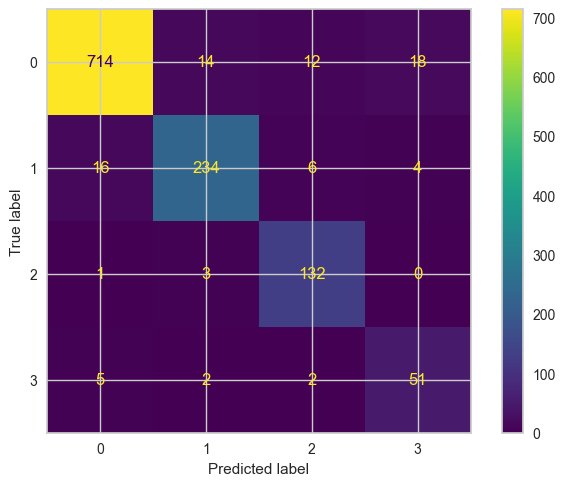

In [71]:
ConfusionMatrixDisplay.from_estimator(log_grid, X_test, y_test);

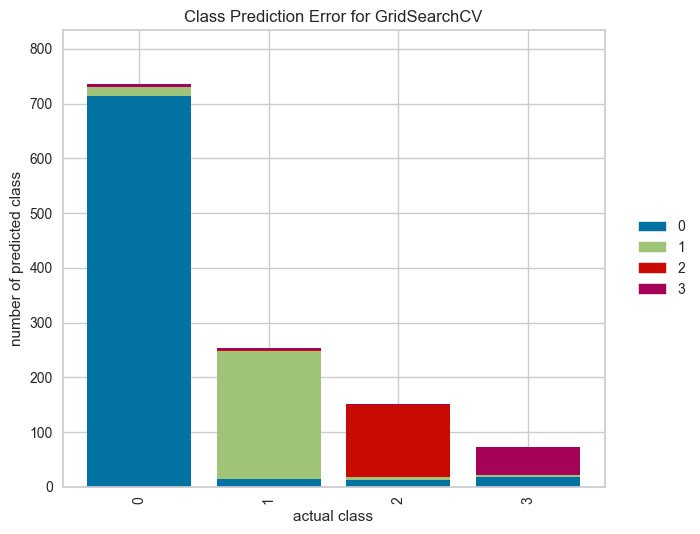

<Axes: title={'center': 'Class Prediction Error for GridSearchCV'}, xlabel='actual class', ylabel='number of predicted class'>

In [72]:
visualizer = ClassPredictionError(log_grid)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

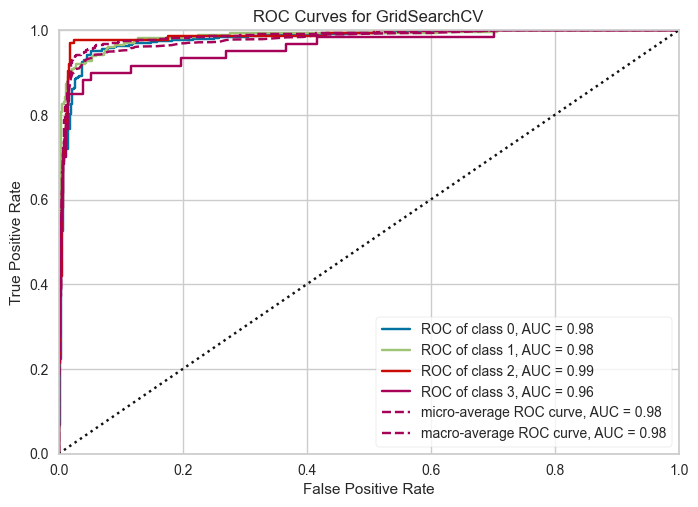

<Axes: title={'center': 'ROC Curves for GridSearchCV'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [73]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(log_grid, classes=[str(i) for i in range(4)])

visualizer.fit(X_train, y_train)        
visualizer.score(X_test, y_test)        
visualizer.show() 

In [74]:
log_results_df = pd.DataFrame(
    {
        "LogReg (Vanilla)": [
            log_reg_accuracy,
            log_reg_f1
        ],
        "LogReg (GridSearch)": [
            log_grid_accuracy,
            log_grid_f1
        ]
    },
    index=["Accuracy", "F1 Score"]
)

log_results_df

,LogReg (Vanilla),LogReg (GridSearch)
Accuracy,0.93,0.93
F1 Score,0.88,0.89


## SVC

In [75]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### Vanilla SVM

In [76]:
pipe_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        random_state=42
    ))
])

pipe_svm.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,C,1.0


In [77]:
y_pred_svc = pipe_svm.predict(X_test)

In [78]:
svc_accuracy = accuracy_score(y_test, y_pred_svc)
svc_f1 = f1_score(y_test, y_pred_svc, average='macro')

In [79]:
eval_metric(pipe_svm, X_train, y_train, X_test, y_test)

Test_Set
[[718  17  13  10]
 [ 16 233   9   2]
 [  1   2 133   0]
 [ 12   2   2  44]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       758
           1       0.92      0.90      0.91       260
           2       0.85      0.98      0.91       136
           3       0.79      0.73      0.76        60

    accuracy                           0.93      1214
   macro avg       0.88      0.89      0.88      1214
weighted avg       0.93      0.93      0.93      1214


Train_Set
[[2910   28   53   43]
 [  20 1001   14    3]
 [   3    1  537    2]
 [   2    0    0  237]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3034
           1       0.97      0.96      0.97      1038
           2       0.89      0.99      0.94       543
           3       0.83      0.99      0.90       239

    accuracy                           0.97      4854
   macro avg       0.92      0.98      0.95      

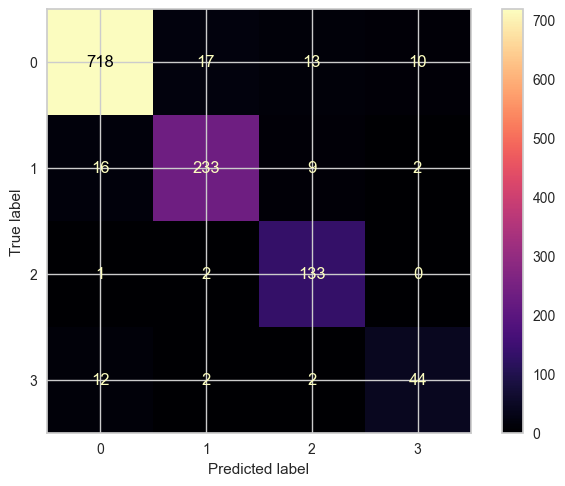

In [80]:
ConfusionMatrixDisplay.from_estimator(pipe_svm, X_test, y_test, cmap = 'magma');

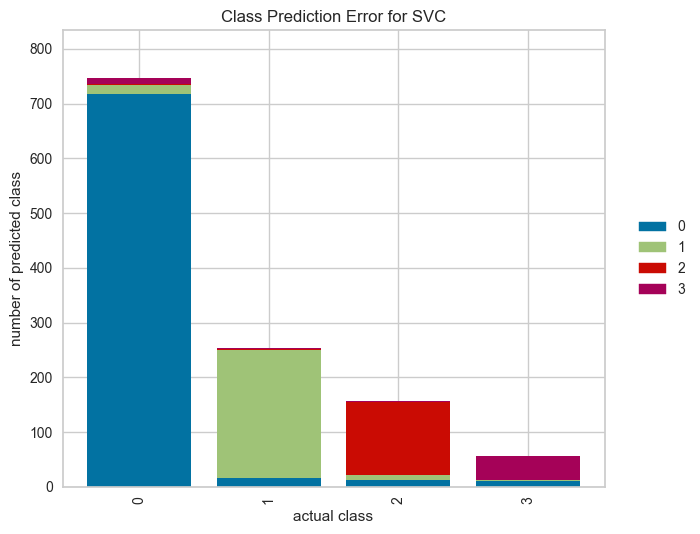

<Axes: title={'center': 'Class Prediction Error for SVC'}, xlabel='actual class', ylabel='number of predicted class'>

In [81]:
visualizer = ClassPredictionError(pipe_svm)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

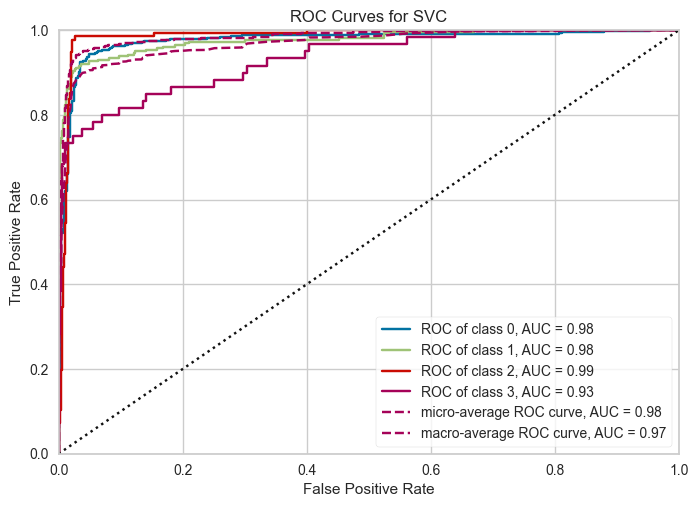

<Axes: title={'center': 'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [82]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(pipe_svm, classes=[str(i) for i in range(4)])

visualizer.fit(X_train, y_train)        
visualizer.score(X_test, y_test)        
visualizer.show() 

### SVM GridsearchCV

In [83]:
param_grid = {
   "model__kernel": ["rbf"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.1, 0.01]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_grid = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 0.1, ...], 'model__kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [84]:
svm_grid.best_params_

{'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

In [85]:
svm_grid.best_score_

np.float64(0.9264533322008346)

In [86]:
svm_grid.best_estimator_

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,C,1


In [87]:
y_pred_test = svm_grid.predict(X_test)
y_pred_train = svm_grid.predict(X_train)

In [88]:
svc_grid_accuracy = accuracy_score(y_test, y_pred_test)
svc_grid_f1 = f1_score(y_test, y_pred_test, average='macro')

In [89]:
svc_results_df = pd.DataFrame(
    {
        "SVC (Vanilla)": [
            svc_accuracy,
            svc_f1
        ],
        "SVC (GridSearch)": [
            svc_grid_accuracy,
            svc_grid_f1
        ]
    },
    index=["Accuracy", "F1 Score"]
)

svc_results_df

,SVC (Vanilla),SVC (GridSearch)
Accuracy,0.93,0.93
F1 Score,0.88,0.88


## RF

### Vanilla RF

In [90]:
pipe_rfc = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

pipe_rfc.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [91]:
y_pred_test = pipe_rfc.predict(X_test)
y_pred_train = pipe_rfc.predict(X_train)

In [92]:
rfc_accuracy = accuracy_score(y_test, y_pred_test)
rfc_f1 = f1_score(y_test, y_pred_test, average='macro')

In [93]:
eval_metric(pipe_rfc, X_train, y_train, X_test, y_test)

Test_Set
[[723   8  13  14]
 [  2 246   9   3]
 [  1   2 133   0]
 [  1  11   2  46]]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       758
           1       0.92      0.95      0.93       260
           2       0.85      0.98      0.91       136
           3       0.73      0.77      0.75        60

    accuracy                           0.95      1214
   macro avg       0.87      0.91      0.89      1214
weighted avg       0.95      0.95      0.95      1214


Train_Set
[[3034    0    0    0]
 [   0 1038    0    0]
 [   0    0  543    0]
 [   0    0    0  239]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3034
           1       1.00      1.00      1.00      1038
           2       1.00      1.00      1.00       543
           3       1.00      1.00      1.00       239

    accuracy                           1.00      4854
   macro avg       1.00      1.00      1.00      

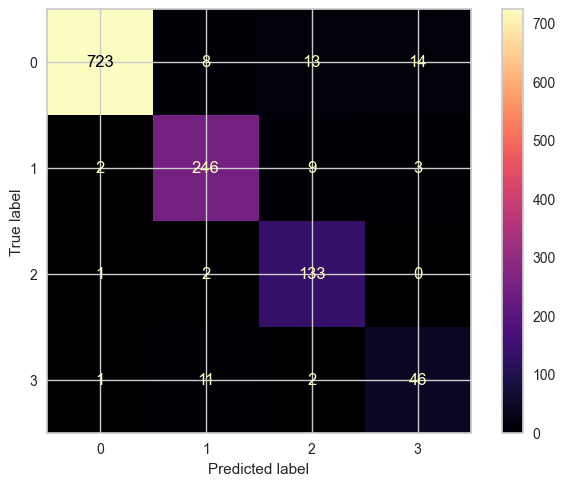

In [94]:
ConfusionMatrixDisplay.from_estimator(pipe_rfc, X_test, y_test, cmap = 'magma');

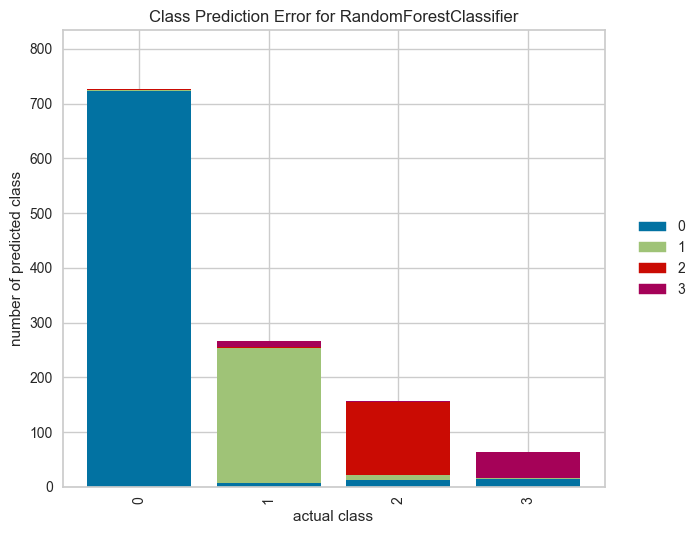

<Axes: title={'center': 'Class Prediction Error for RandomForestClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [95]:
visualizer = ClassPredictionError(pipe_rfc)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

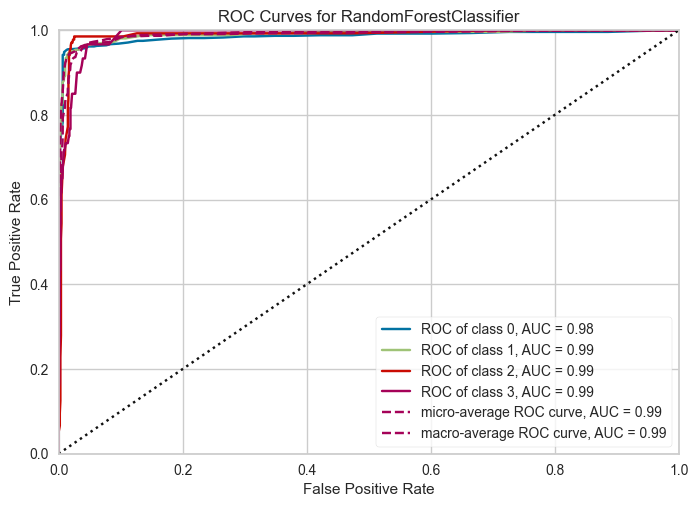

<Axes: title={'center': 'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [96]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(pipe_rfc, classes=[str(i) for i in range(4)])

visualizer.fit(X_train, y_train)        
visualizer.score(X_test, y_test)        
visualizer.show() 

### RF GridsearchCV

In [97]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__max_features": ["sqrt", 0.8],   # ⚠️ 'auto' deprecated
    "model__n_estimators": [50, 100, 150]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid_model = GridSearchCV(
    estimator=pipe_rfc,
    param_grid=param_grid,
    verbose=2,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

rf_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 4, ...], 'model__max_features': ['sqrt', 0.8], 'model__n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [98]:
rf_grid_model.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 8,
 'model__max_features': 0.8,
 'model__n_estimators': 150}

In [99]:
rf_grid_model.best_score_

np.float64(0.9470546890759872)

In [100]:
rf_grid_model.best_estimator_

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,n_estimators,150
,criterion,'entropy'
,max_depth,8
,min_samples_split,2


In [101]:
y_pred_test = rf_grid_model.predict(X_test)
y_pred_train = rf_grid_model.predict(X_train)

In [102]:
rf_grid_accuracy = accuracy_score(y_test, y_pred_test)
rf_grid_f1 = f1_score(y_test, y_pred_test, average='macro')

In [103]:
eval_metric(rf_grid_model, X_train, y_train, X_test, y_test)

Test_Set
[[726   6  13  13]
 [  2 244   7   7]
 [  1   2 133   0]
 [  2   5   2  51]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       758
           1       0.95      0.94      0.94       260
           2       0.86      0.98      0.91       136
           3       0.72      0.85      0.78        60

    accuracy                           0.95      1214
   macro avg       0.88      0.93      0.90      1214
weighted avg       0.96      0.95      0.95      1214


Train_Set
[[2947   11   44   32]
 [   0 1026    5    7]
 [   1    1  539    2]
 [   8    1    7  223]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      3034
           1       0.99      0.99      0.99      1038
           2       0.91      0.99      0.95       543
           3       0.84      0.93      0.89       239

    accuracy                           0.98      4854
   macro avg       0.93      0.97      0.95      

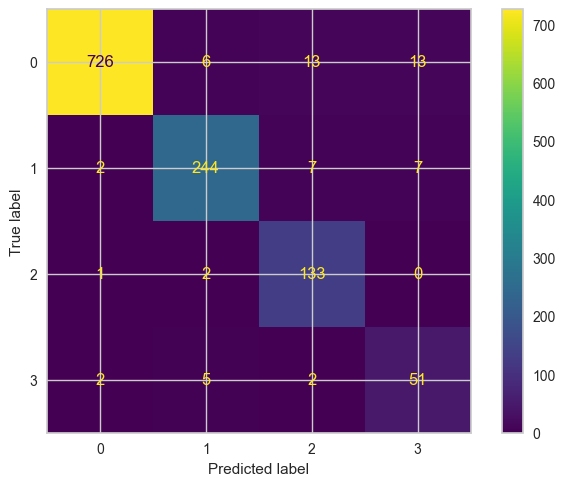

In [104]:
ConfusionMatrixDisplay.from_estimator(rf_grid_model, X_test, y_test);

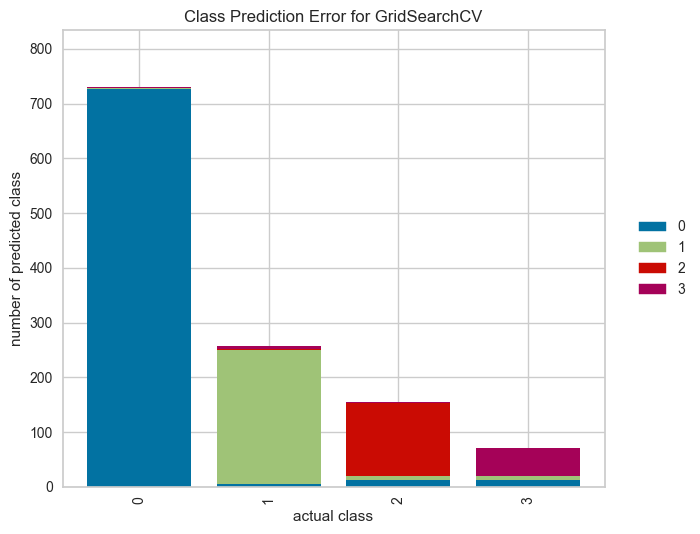

<Axes: title={'center': 'Class Prediction Error for GridSearchCV'}, xlabel='actual class', ylabel='number of predicted class'>

In [105]:
visualizer = ClassPredictionError(rf_grid_model)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

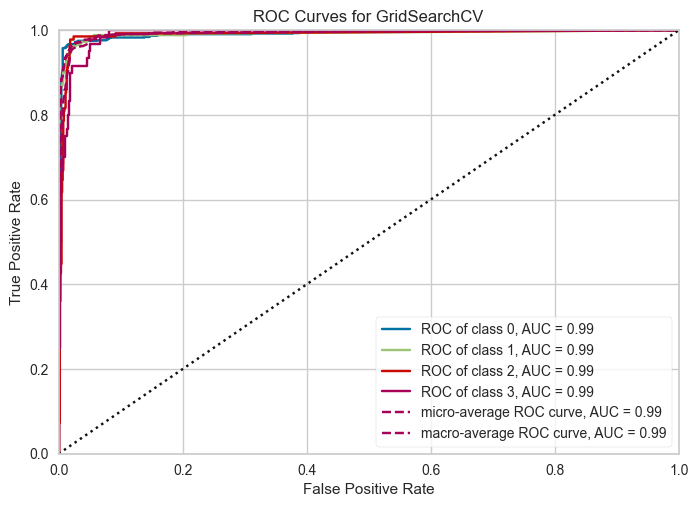

<Axes: title={'center': 'ROC Curves for GridSearchCV'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [106]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(rf_grid_model, classes=[str(i) for i in range(4)])

visualizer.fit(X_train, y_train)        
visualizer.score(X_test, y_test)        
visualizer.show() 

In [107]:
rf_results_df = pd.DataFrame(
    {
        "RF (Vanilla)": [
            rfc_accuracy,
            rfc_f1
        ],
        "RF (GridSearch)": [
            rf_grid_accuracy,
            rf_grid_f1
        ]
    },
    index=["Accuracy", "F1 Score"]
)

rf_results_df

,RF (Vanilla),RF (GridSearch)
Accuracy,0.95,0.95
F1 Score,0.89,0.90


## Boosting Methods

### Vanilla XGBoost

In [108]:
pipe_xgb = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42
    ))
])

pipe_xgb.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None


In [109]:
y_pred_test = pipe_xgb.predict(X_test)
y_pred_train = pipe_xgb.predict(X_train)

In [110]:
xgb_accuracy = accuracy_score(y_test, y_pred_test)
xgb_f1 = f1_score(y_test, y_pred_test, average='macro')

In [111]:
eval_metric(pipe_xgb, X_train, y_train, X_test, y_test)

Test_Set
[[730   4  13  11]
 [  4 245   7   4]
 [  2   2 132   0]
 [  4   6   2  48]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       758
           1       0.95      0.94      0.95       260
           2       0.86      0.97      0.91       136
           3       0.76      0.80      0.78        60

    accuracy                           0.95      1214
   macro avg       0.89      0.92      0.90      1214
weighted avg       0.95      0.95      0.95      1214


Train_Set
[[3034    0    0    0]
 [   0 1038    0    0]
 [   0    0  543    0]
 [   0    0    0  239]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3034
           1       1.00      1.00      1.00      1038
           2       1.00      1.00      1.00       543
           3       1.00      1.00      1.00       239

    accuracy                           1.00      4854
   macro avg       1.00      1.00      1.00      

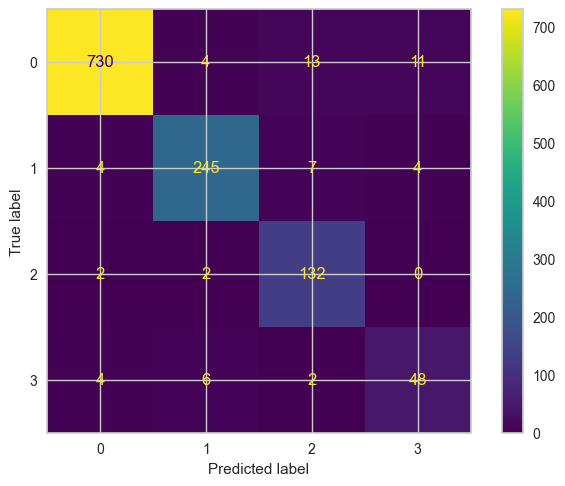

In [112]:
ConfusionMatrixDisplay.from_estimator(pipe_xgb, X_test, y_test);

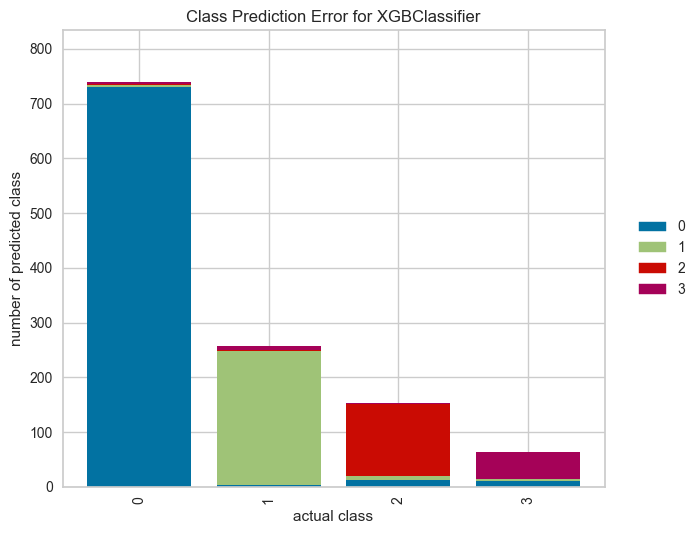

<Axes: title={'center': 'Class Prediction Error for XGBClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [113]:
visualizer = ClassPredictionError(pipe_xgb)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

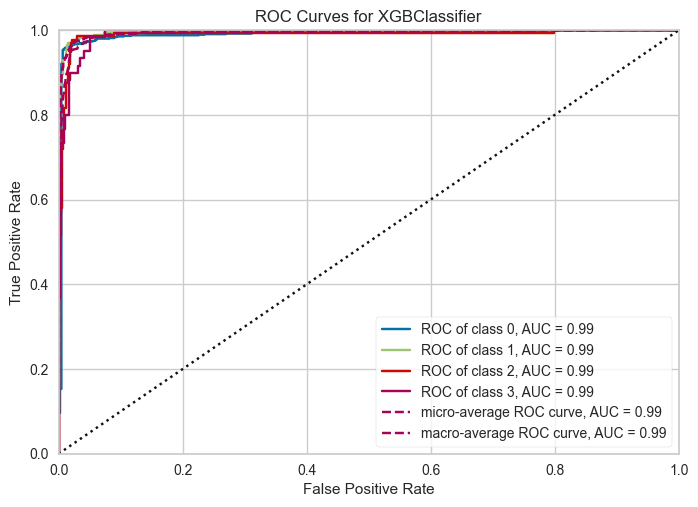

<Axes: title={'center': 'ROC Curves for XGBClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [114]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(pipe_xgb, classes=[str(i) for i in range(4)])

visualizer.fit(X_train, y_train)        
visualizer.score(X_test, y_test)        
visualizer.show()

### XGBoost GridSearchCV

In [ ]:
param_grid = {
    "model__n_estimators": [80, 100, 150, 200],
    'model__max_depth': [4,5,6,7],
    "model__learning_rate": [0.05, 0.1, 0.5],
    "model__subsample": [0.5, 0.8, 1],          
    "model__colsample_bytree": [0.3, 0.5, 0.7]  
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_grid = GridSearchCV(pipe_xgb, 
                        param_grid, 
                        cv = cv, 
                        scoring = "accuracy", 
                        n_jobs = -1, 
                        verbose = 1, 
                        return_train_score = True)
xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


In [ ]:
xgb_grid.best_params_

In [ ]:
xgb_grid.best_score_

In [ ]:
y_pred_test = xgb_grid.predict(X_test)
y_pred_train = xgb_grid.predict(X_train)

In [ ]:
xgb_grid_accuracy = accuracy_score(y_test, y_pred_test)
xgb_grid_f1 = f1_score(y_test, y_pred_test, average='macro')


In [ ]:
eval_metric(xgb_grid,X_train, y_train, X_test, y_test)

In [ ]:
ConfusionMatrixDisplay.from_estimator(xgb_grid, X_test, y_test);

In [ ]:
visualizer = ClassPredictionError(xgb_grid)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

In [ ]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(xgb_grid, classes=[str(i) for i in range(4)])

visualizer.fit(X_train, y_train)        
visualizer.score(X_test, y_test)        
visualizer.show()

In [ ]:
xgb_results_df = pd.DataFrame(
    {
        "XGB (Vanilla)": [
            xgb_accuracy,
            xgb_f1
        ],
        "XGB (GridSearch)": [
            xgb_grid_accuracy,
            xgb_grid_f1
        ]
    },
    index=["Accuracy", "F1 Score"]
)
xgb_results_df

## Comparing Models

In [ ]:
all_results_df = pd.concat(
    [
        rf_results_df,
        log_results_df,
        svc_results_df,
        xgb_results_df
    ],
    axis=1
)

all_results_df

In [ ]:
# Verileri al
accuracy = all_results_df.loc["Accuracy"]
f1 = all_results_df.loc["F1 Score"]

models = accuracy.index
x = np.arange(len(models))
width = 0.35

plt.figure()
bars_acc = plt.bar(x - width/2, accuracy, width, label="Accuracy")
bars_f1 = plt.bar(x + width/2, f1, width, label="F1 Score (Macro)")

# Y ekseni 0.8 – 1.0
plt.ylim(0.8, 1.0)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs F1 Score")
plt.xticks(x, models, rotation=45, ha="right")
plt.legend()

# Barların üstüne değer yaz
for bars in [bars_acc, bars_f1]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

In [ ]:

accuracy = all_results_df.loc["Accuracy"]

plt.figure()
plt.barh(accuracy.index, accuracy)
plt.xlim(0.8, 1.0)
plt.xlabel("Accuracy")
plt.title("Model Comparison - Accuracy")

for i, v in enumerate(accuracy):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

In [ ]:
f1 = all_results_df.loc["F1 Score"]

plt.figure()
plt.barh(f1.index, f1)
plt.xlim(0.8, 1.0)
plt.xlabel("F1 Score (Macro)")
plt.title("Model Comparison - F1 Score")

for i, v in enumerate(f1):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

# Before the Deployment 

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import pickle

In [ ]:
xgb_best = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.3,
    random_state=42,
)

In [ ]:
final_pipeline = Pipeline(steps=[
    ("smote", SMOTE(sampling_strategy="auto", random_state=42)),
    ("model", xgb_best)
])

In [ ]:
final_pipeline.fit(X, y)

In [ ]:
pickle.dump(final_pipeline, open("xgboost_smote_pipeline.pkl", "wb"))

#  SHAP

In [ ]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(xgb_best)


In [ ]:
shap_values = explainer.shap_values(X_test)


In [ ]:
type(shap_values) 

In [ ]:
len(shap_values)

In [ ]:
shap_values[0].shape 

In [ ]:
# class bazlı SHAP almak
shap_values_class0 = shap_values[:, :, 0]
shap_values_class1 = shap_values[:, :, 1]
shap_values_class2 = shap_values[:, :, 2]
shap_values_class3 = shap_values[:, :, 3]


In [ ]:
print(shap_values.shape)
print(X_test.shape)

In [ ]:
for class_id in range(4):
    shap.summary_plot(
        shap_values[:, :, class_id],
        X_test,
        show=True
    )
    

🔹 SHAP Analizi – Genel Değerlendirme

Aşağıda sunulan SHAP summary plot’lar, XGBoost modelinin her bir DODRace sınıfı için tahmin üretirken hangi değişkenlere ne yönde ve ne ölçüde dayandığını göstermektedir.
Grafiklerde yatay eksen SHAP değerlerini (model çıktısına etki yönü ve büyüklüğü), renk skalası ise ilgili feature’ın düşük–yüksek değerlerini temsil etmektedir.

Bu analiz sayesinde modelin:

hangi sınıfları hangi antropometrik ve demografik değişkenlerle ayırt ettiği,

karar mekanizmasının biyolojik ve demografik olarak ne kadar tutarlı olduğu

yorumlanabilmektedir.

🔹 DODRace – Class 0 için SHAP Yorumu

Class 0 için elde edilen SHAP sonuçları incelendiğinde, modelin tahminlerinde en baskın değişkenlerin SubjectNumericRace, Ethnicity (Other) ve SubjectsBirthLocation_USA olduğu görülmektedir.

Bu sınıfta:

SubjectNumericRace değişkeninin yüksek değerleri, model çıktısını güçlü biçimde bu sınıfa doğru itmektedir.

Ethnicity_Other kategorisinin yüksek SHAP değerleri, bu sınıf için ayırt edici bir rol oynamaktadır.

Antropometrik ölçülerden interpupillary breadth, eye height (sitting) ve lateral malleolus height gibi baş ve alt ekstremite ölçülerinin ikincil fakat tutarlı katkılar sunduğu gözlemlenmektedir.

Bu bulgular, Class 0 tahminlerinin ağırlıklı olarak demografik kodlanmış değişkenler üzerinden şekillendiğini, fiziksel ölçülerin ise destekleyici rol oynadığını göstermektedir.

🔹 DODRace – Class 1 için SHAP Yorumu

Class 1 için SHAP dağılımları, modelin bu sınıfı ayırt ederken hem demografik hem de morfolojik ölçüleri birlikte kullandığını göstermektedir.

Öne çıkan noktalar:

Ethnicity_Hispanic / Latino değişkeni, bu sınıf için en belirgin pozitif katkıyı sağlayan feature’lardan biridir.

bicristal breadth, interpupillary breadth ve ear length gibi baş ve yüz genişliği ile ilişkili ölçülerin etkisi belirgindir.

SubjectNumericRace değişkeninin SHAP değerleri, bu sınıfta da anlamlı bir ayırt edicilik sunmaktadır.

Bu sonuçlar, Class 1 tahminlerinde modelin etnik köken göstergeleri ile belirli yüz ve iskelet ölçülerini birlikte değerlendirdiğini ortaya koymaktadır.

🔹 DODRace – Class 2 için SHAP Yorumu

Class 2’ye ait SHAP grafiği incelendiğinde, modelin bu sınıfı diğerlerinden ayırırken vücut uzunluğu ve ekstremite ölçülerine daha fazla ağırlık verdiği görülmektedir.

Özellikle:

buttock–knee length, lateral malleolus height ve hand length gibi alt ve üst ekstremite uzunlukları,

chest circumference ve bimalleolar breadth gibi çevresel ölçüler

model çıktısını bu sınıf yönünde etkileyen başlıca faktörlerdir.

Demografik değişkenlerin etkisi bu sınıfta görece daha sınırlı olup, karar mekanizmasının daha çok antropometrik farklılıklara dayandığı söylenebilir.

🔹 DODRace – Class 3 için SHAP Yorumu

Class 3 için SHAP sonuçları, modelin bu sınıfı ayırt ederken hem etnik/demografik göstergeleri hem de baş ve yüz ölçülerini birlikte kullandığını göstermektedir.

Öne çıkan bulgular:

Ethnicity_Other ve Ethnicity_Hispanic / Latino değişkenleri, bu sınıf için güçlü yönlü etkilere sahiptir.

bizygomatic breadth, head length, head circumference ve ear protrusion gibi kraniofasiyal ölçüler model kararında belirleyici rol oynamaktadır.

SubjectsBirthLocation_USA değişkeninin bazı gözlemler için sınırlı ama tutarlı bir katkı sunduğu gözlemlenmektedir.

Bu durum, Class 3 tahminlerinde modelin özellikle baş ve yüz morfolojisi ile etnik köken bilgilerini birlikte kullandığını göstermektedir.

🔹 Genel Sonuç

Tüm sınıflar birlikte değerlendirildiğinde SHAP analizi, XGBoost modelinin:

demografik kodlanmış değişkenleri (Ethnicity, SubjectNumericRace, Birth Location),

antropometrik ölçülerle birlikte ve tutarlı biçimde kullandığını,

ve sınıflar arasında farklı fiziksel ve demografik profiller öğrenerek ayrım yaptığını ortaya koymaktadır.

Bu bulgular, modelin karar mekanizmasının rastgele değil, veri setindeki anlamlı biyolojik ve demografik örüntülere dayandığını göstermektedir.

In [ ]:
for class_id in range(4):
    shap.summary_plot(
        shap_values[:, :, class_id],
        X_test,
        plot_type="bar",
        show=True
    )

🔹 SHAP Bar Plot – Class 0

Class 0 için SHAP bar plot, modelin bu sınıfı ayırt ederken en baskın değişken olarak SubjectNumericRace bilgisini kullandığını göstermektedir. Bunu Ethnicity_Other ve SubjectsBirthLocation_USA takip etmektedir. Antropometrik ölçüler (interpupillary breadth, eye height sitting, lateral malleolus height) daha düşük etki düzeyinde olup, demografik değişkenlere kıyasla ikincil rol oynamaktadır.

🔹 SHAP Bar Plot – Class 1

Class 1’de SubjectNumericRace yine en yüksek ortalama SHAP değerine sahiptir. Bunun yanında Ethnicity_Hispanic / Latino ve bicristal breadth gibi yüz ve kafa genişliğiyle ilişkili ölçüler öne çıkmaktadır. Bu durum, modelin Class 1 tahminlerinde etnik köken bilgisi ile belirli kraniofasiyal ölçüleri birlikte kullandığını göstermektedir.

🔹 SHAP Bar Plot – Class 2

Class 2 için bar plot sonuçları, Ethnicity_Hispanic / Latino ve Ethnicity_Other değişkenlerinin bu sınıf için en belirleyici faktörler olduğunu göstermektedir. SubjectNumericRace üçüncü sırada yer alırken, buttock–knee length ve lateral malleolus height gibi alt ekstremite ölçüleri daha sınırlı fakat tutarlı katkılar sunmaktadır.

🔹 SHAP Bar Plot – Class 3

Class 3’te SubjectNumericRace ve Ethnicity_Other değişkenleri açık ara en yüksek etkiye sahiptir. Bunları Ethnicity_Hispanic / Latino ve bizygomatic breadth takip etmektedir. Bu sonuçlar, modelin Class 3 tahminlerinde hem demografik kodlanmış değişkenleri hem de yüz genişliğiyle ilişkili ölçüleri birlikte kullandığını ortaya koymaktadır.

In [ ]:
row = 10

for class_id in range(4):
    print(f"Class {class_id}")
    shap.force_plot(
        explainer.expected_value[class_id],
        shap_values[row, :, class_id],
        X_test.iloc[row],
        matplotlib=True
    )

🔹 SHAP Force Plot – Class 0 (Tekil Gözlem)

Bu gözlem için model çıktısı, base value’dan aşağı yönlü saparak Class 0 olasılığını düşürmüştür.
SubjectNumericRace = 2 ve Ethnicity_Other = 1 değişkenleri tahmini aşağı çeken (mavi) en baskın faktörlerdir. Buna karşılık bitragonchin arc gibi bazı antropometrik ölçüler sınırlı da olsa pozitif katkı sağlamıştır. Genel olarak demografik değişkenlerin etkisi, fiziksel ölçümlerin önüne geçmiştir.

🔹 SHAP Force Plot – Class 1 (Tekil Gözlem)

Class 1 için model çıktısı base value’nun üzerine taşınmıştır. Bu artışın ana nedeni SubjectNumericRace = 2 ve Ethnicity_Other = 1 değişkenlerinin güçlü pozitif (kırmızı) katkılarıdır. Bicristal breadth ölçüsü ise tahmini aşağı yönlü etkileyerek dengeleyici bir rol oynamıştır. Model bu gözlemde demografik bilgileri belirleyici sinyal olarak kullanmıştır.

🔹 SHAP Force Plot – Class 2 (Tekil Gözlem)

Bu sınıf için tahmin değeri base value’nun oldukça altında kalmıştır. Ethnicity_Hispanic / Latino = 0, Ethnicity_Other = 1 ve SubjectNumericRace = 2 değişkenleri birlikte güçlü negatif katkı üretmiştir. Bu durum, gözlemin Class 2 profiliyle uyumsuz olduğunu ve modelin bu sınıfı net şekilde dışladığını göstermektedir.

🔹 SHAP Force Plot – Class 3 (Tekil Gözlem)

Class 3 için model çıktısı yine base value’nun altına çekilmiştir. SubjectNumericRace = 2 ve Ethnicity_Other = 1 değişkenleri tahmini aşağı yönlü etkileyen temel faktörlerdir. Ethnicity_Hispanic / Latino = 0 değişkeni de bu negatif katkıyı güçlendirmiştir. Fiziksel ölçümlerin katkısı sınırlı kalmış, karar ağırlıklı olarak demografik sinyaller üzerinden verilmiştir.

Force plot’lar, modelin tekil tahminlerde ağırlıklı olarak SubjectNumericRace ve ethnicity tabanlı değişkenlere dayandığını; antropometrik ölçülerin ise daha çok destekleyici rol oynadığını göstermektedir. Bu durum, sınıflar arası ayrımda demografik kodlanmış bilgilerin baskın sinyal olduğunu ortaya koymaktadır.

In [ ]:
n_samples = 100  # çok önemli, yoksa grafik çöplüğe döner

for class_id in range(4):
    print(f"Class {class_id}")
    shap.decision_plot(
        explainer.expected_value[class_id],
        shap_values[:n_samples, :, class_id],
        X_test.iloc[:n_samples],
        show=True
    )

🔹 SHAP Decision Plot – Class 0

Class 0 için decision plot, model çıktısının ağırlıklı olarak SubjectNumericRace, Ethnicity_Other ve SubjectsBirthLocation_USA değişkenleri tarafından belirlendiğini göstermektedir. Gözlemler arasında bu değişkenlerin katkısı tutarlı bir şekilde negatif yönde yoğunlaşmaktadır. Antropometrik ölçüler daha sınırlı etkiye sahip olup, karar sürecinde ikincil rol oynamaktadır.

🔹 SHAP Decision Plot – Class 1

Class 1’de model çıktısı, SubjectNumericRace ve Ethnicity_Other değişkenlerinin pozitif yöndeki katkılarıyla belirgin şekilde artmaktadır. Bicristal breadth ve diğer kraniofasiyal ölçüler bazı gözlemlerde ayrışma yaratmakla birlikte, genel karar yapısında demografik değişkenler baskın sinyal olarak öne çıkmaktadır.

🔹 SHAP Decision Plot – Class 2

Class 2 için decision plot, Ethnicity_Hispanic / Latino ve Ethnicity_Other değişkenlerinin model çıktısını aşağı yönlü sürüklediğini göstermektedir. SubjectNumericRace değişkeni bu etkiyi güçlendiren temel faktörlerden biridir. Fiziksel ölçümlerin katkısı sınırlı kalmış ve çoğunlukla karar sınırı etrafında küçük sapmalar üretmiştir.

🔹 SHAP Decision Plot – Class 3

Class 3’te decision plot, SubjectNumericRace, Ethnicity_Other ve Ethnicity_Hispanic / Latino değişkenlerinin birlikte güçlü ve tutarlı bir etki yarattığını göstermektedir. Bu değişkenler, gözlemlerin büyük çoğunluğunda model çıktısını aynı yönde hareket ettirmektedir. Antropometrik ölçüler ise sınıflandırmayı destekleyici ancak belirleyici olmayan katkılar sunmaktadır.

In [ ]:
for class_id in range(4):
    print(f"Class {class_id}")
    shap.summary_plot(
        shap_values[:, :, class_id],
        X_test,
        plot_type="violin",
        show=True
    )

🔹 SHAP Violin Summary Plot – Class 0

Class 0 için violin plot, SubjectNumericRace değişkeninin hem en geniş SHAP dağılımına hem de en yüksek etkiye sahip olduğunu göstermektedir. Ethnicity_Other ve SubjectsBirthLocation_USA değişkenleri daha dar fakat tutarlı katkılar sunmaktadır. Antropometrik ölçülerin SHAP dağılımları sıfıra daha yakın yoğunlaşmış olup, bu sınıf için ikincil rol oynadıklarını göstermektedir.

🔹 SHAP Violin Summary Plot – Class 1

Class 1’de SubjectNumericRace yine en baskın değişken olarak öne çıkmaktadır. Ethnicity_Other ve bicristal breadth değişkenlerinin SHAP dağılımları daha geniştir ve bazı gözlemlerde belirgin pozitif katkılar üretmektedir. Bu durum, Class 1 tahminlerinde hem demografik hem de kraniofasiyal ölçülerin birlikte etkili olduğunu göstermektedir.

🔹 SHAP Violin Summary Plot – Class 2

Class 2 için violin plot sonuçları, Ethnicity_Hispanic / Latino ve Ethnicity_Other değişkenlerinin geniş ve asimetrik SHAP dağılımlarına sahip olduğunu ortaya koymaktadır. SubjectNumericRace değişkeni bu etkiyi desteklerken, antropometrik ölçüler daha dar dağılımlar sergileyerek sınırlı katkı sunmaktadır. Model, bu sınıfı ayırt ederken ağırlıklı olarak etnik köken bilgisine dayanmaktadır.

🔹 SHAP Violin Summary Plot – Class 3

Class 3’te SubjectNumericRace, Ethnicity_Other ve Ethnicity_Hispanic / Latino değişkenleri en geniş SHAP dağılımlarını göstermektedir. Bu değişkenlerin hem pozitif hem negatif yönde güçlü etkiler üretmesi, modelin bu sınıf için karar sınırını ağırlıklı olarak demografik sinyaller üzerinden şekillendirdiğini göstermektedir. Fiziksel ölçüler daha dar dağılımlar ile destekleyici rol üstlenmektedir.

In [ ]:
feature_name = "acromialheight"

for class_id in range(4):
    print(f"Class {class_id}")
    shap.dependence_plot(
        feature_name,
        shap_values[:, :, class_id],
        X_test,
        interaction_index=None
    )